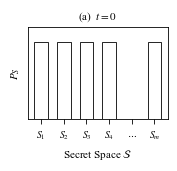

In [58]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Linux Libertine O', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.figsize': (1.8, 1.2),
    'lines.markersize': 1,
    'lines.linewidth': 0.6,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'mathtext.fontset': 'stix',
})

x_positions = [1, 2, 3, 4, 6] 
heights = [1, 1, 1, 1, 1]
# no color, solid border bars
plt.bar(x_positions, heights, color='none', edgecolor='black', linewidth=0.6, width=0.6)
# set x ticks and labels
plt.xticks([1,2,3,4,5,6], ['$S_1$', '$S_2$', '$S_3$', '$S_4$', r'$\cdots$', '$S_m$'])
# y lim is 1.2
plt.ylim(0, 1.2)
# hide y ticks and tick labels
plt.yticks([])
plt.ylabel('$P_S$')
plt.xlabel(r'Secret Space $\mathcal{S}$')
plt.title('(a)  $t=0$')
plt.savefig('fig/p_s_uniform.pdf', bbox_inches='tight', pad_inches=0.01)

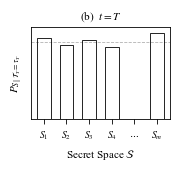

In [59]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Linux Libertine O', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.figsize': (1.8, 1.2),
    'lines.markersize': 1,
    'lines.linewidth': 0.6,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'mathtext.fontset': 'stix',
})

x_positions = [1, 2, 3, 4, 6] 
heights = [1.05, 0.97, 1.03, 0.94, 1.12]
# no color, solid border bars
plt.bar(x_positions, heights, color='none', edgecolor='black', linewidth=0.6, width=0.6)
# set x ticks and labels
plt.xticks([1,2,3,4,5,6], ['$S_1$', '$S_2$', '$S_3$', '$S_4$', r'$\cdots$', '$S_m$'])
# y lim is 1.2
plt.ylim(0, 1.2)
# hide y ticks and tick labels
# one horizontal line at y=1
plt.axhline(y=1, color='black', linestyle='--', linewidth=0.6, alpha=0.3)
plt.yticks([])
plt.ylabel(r'$P_{S\mid\mathcal{T}_T=\tau_T}$')
plt.xlabel(r'Secret Space $\mathcal{S}$')
plt.title('(b)  $t=T$')
plt.savefig('fig/p_s_nonuniform.pdf', bbox_inches='tight', pad_inches=0.01)

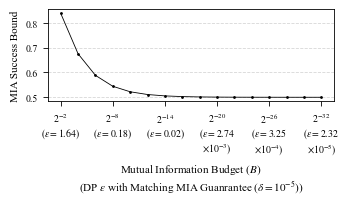

In [ ]:
import matplotlib.pyplot as plt
from pac_privacy_utils import posterior_success_guarantee, posterior_success_rate_to_epsilon
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Linux Libertine O', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.figsize': (3.7, 1.2), # single column width
    'lines.markersize': 1,
    'lines.linewidth': 0.6,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'mathtext.fontset': 'stix',
})

log2_mi_bounds = np.arange(-32, 0, 2)
mi_bounds = 2.0**log2_mi_bounds
posterior_successes = [posterior_success_guarantee(mi_bound) for mi_bound in mi_bounds]

plt.figure() 

plt.plot(mi_bounds, posterior_successes, marker='o', color='black')
plt.xlabel("Mutual Information Budget ($B$)"  + "\n" + r"(DP $\varepsilon$ with Matching MIA Guanrantee ($\delta=10^{-5}$))")
plt.ylabel("MIA Success Bound")

plt.xscale('log', base=2)
plt.xticks([2.0**(-2-6*k) for k in [5,4,3,2,1,0]])
tick_mis = [2.0**(-2-6*k) for k in [5,4,3,2,1,0]]
tick_epsilons = [posterior_success_rate_to_epsilon(posterior_success_guarantee(mi)) for mi in tick_mis]
a = [f"{eps:.2e}" for eps in tick_epsilons]


def sci_no_pad(x, precision=2, sci_precision=2):
    # If rounding keeps information, use normal formatting
    if round(x, precision) != 0:
        return f"{x:.{precision}f}".rstrip('0').rstrip('.')

    # Otherwise use scientific notation
    s = f"{x:.{sci_precision}e}"
    mantissa, exp = s.split('e')
    mantissa = mantissa.rstrip('0').rstrip('.')
    exp = int(exp)  # removes leading zeros

    return mantissa if exp == 0 else f"{mantissa}e{exp}"

a = [f"{sci_no_pad(eps)}" for eps in tick_epsilons]
# replace "e" to "×10^"
tick_epsilons_str = [s.replace("e", r"$" + "\n" + r"$\times 10^{") + "}" if "e" in s else s for s in a]
tick_epsilons_str = [r"($\varepsilon=" + s + r"$)" for s in tick_epsilons_str]

# override x tick labels to print the epsilon equivalents below the mi numbers
xtick_labels = [f"$2^{{-{2+6*k}}}$" for k in [5,4,3,2,1,0]]
for i in range(len(xtick_labels)):
    xtick_labels[i] += "\n" + tick_epsilons_str[i]
plt.gca().set_xticklabels(xtick_labels)
plt.grid(axis='y', linestyle='--', alpha=0.5, linewidth=0.6)
plt.gca().invert_xaxis()

plt.savefig('fig/mi_to_delta.pdf', bbox_inches='tight', pad_inches=0.01)
plt.show()

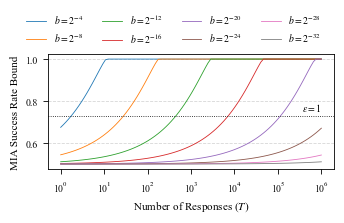

In [2]:
import matplotlib.pyplot as plt
from pac_privacy_utils import posterior_success_guarantee, epsilon_to_posterior_success_rate, mi_bound
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Linux Libertine O', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.figsize': (3.7, 1.5),
    'lines.markersize': 1,
    'lines.linewidth': 0.6,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'mathtext.fontset': 'stix',
})

# colors = [(240, 108, 111), (142, 197, 142), (204, 112, 73), (91, 197, 197), (255, 197, 91), (91, 142, 197), (248, 134, 77), (197, 142, 197)]

bs = [-4, -8, -12, -16, -20, -24, -28, -32]
Ts = np.logspace(0, 6, num=100)

p = epsilon_to_posterior_success_rate(1.0, delta=1e-5)
mi_for_eps_1 = mi_bound(p)

plt.figure()
# plot epsilon=1.0 horizontal line
for b in bs:
    plt.plot(Ts, [posterior_success_guarantee(2.0**b * T) for T in Ts], label=r"$b=2^{" + f"{b}" + r"}$")
plt.xscale('log', base=10)
plt.xlabel("Number of Responses ($T$)")
plt.ylabel("MIA Success Rate Bound")
plt.legend(loc='lower center', bbox_to_anchor=(0.44, 1.), ncol=4, frameon=False)
plt.axhline(y=posterior_success_guarantee(mi_for_eps_1), color='black', linestyle=':')
# write epsilon=1.0 next to the line
plt.text(1e6, posterior_success_guarantee(mi_for_eps_1) + 0.01, r"$\varepsilon=1$", fontsize=7, verticalalignment='bottom', horizontalalignment='right')
plt.grid(axis='y', linestyle='--', alpha=0.5, linewidth=0.6)
plt.tick_params(which='minor', bottom=False)
plt.savefig('fig/n_to_delta.pdf', bbox_inches='tight', pad_inches=0.01)

In [3]:
import numpy as np
from pac_privacy_utils import posterior_success_guarantee, mi_bound
import pandas as pd
Ts = [1, 10, 100, 1000, 10000, 100000, 1000000]
bs = [-4, -8, -12, -16, -20, -24, -28, -32]

psr_eps_1 = epsilon_to_posterior_success_rate(1.0, delta=1e-5)
mi_eps_1 = mi_bound(psr_eps_1)
psr_eps_8 = epsilon_to_posterior_success_rate(8.0, delta=1e-5)
mi_eps_8 = mi_bound(psr_eps_8)

def convert_large_number(n):
    if n >= 1e9:
        return f"{n / 1e9:.0f}B"
    elif n >= 1e6:
        return f"{n / 1e6:.0f}M"
    elif n >= 1e3:
        return f"{n / 1e3:.0f}K"
    else:
        return f"{n:.0f}"

# I want a df, headers are the Ts, index are the bs, entries are the posterior success rates
data = []
for b in bs:
    row = {}
    for T in Ts:
        psr = posterior_success_guarantee(2.0**b * T) * 100
        # row[f"{T:,}"] = f"{psr:.2f}" if psr != 100 else 100
        # use $10^{i}$
        key = "$T=10^{" + f"{int(np.log10(T))}" + r"}$"
        if T <= 10:
            key = f"$T={T}$"
        if b < -16:
            row[key] = f"{psr:.2f}" if psr != 100 else 100
        else:
            row[key] = f"{psr:.1f}" if psr != 100 else 100
    t_eps_1 = mi_eps_1 // (2.0**b)
    row[r"$T$ s.t. $\epsilon=1$"] = convert_large_number(t_eps_1)
    
    t_eps_8 = mi_eps_8 // (2.0**b)
    row[r"$T$ s.t. $\epsilon=8$"] = convert_large_number(t_eps_8)
    data.append(row)
df = pd.DataFrame(data, index=[f"$2^{{{b}}}$" for b in bs])
df = df.T
latex = df.to_latex(escape=False, float_format="%.2f", column_format="l" + "r" * (len(df.columns)))
latex = latex.replace("$T$ s.t. $\\epsilon=1$", r"\midrule" + "\n" + r"$T$ s.t. $\epsilon=1$")
# save to file
with open("fig/mi_to_delta_table.tex", "w") as f:
    f.write(latex)
print(latex)

\begin{tabular}{lrrrrrrrr}
\toprule
 & $2^{-4}$ & $2^{-8}$ & $2^{-12}$ & $2^{-16}$ & $2^{-20}$ & $2^{-24}$ & $2^{-28}$ & $2^{-32}$ \\
\midrule
$T=1$ & 67.5 & 54.4 & 51.1 & 50.3 & 50.07 & 50.02 & 50.00 & 50.00 \\
$T=10$ & 98.7 & 63.9 & 53.5 & 50.9 & 50.22 & 50.05 & 50.01 & 50.00 \\
$T=10^{2}$ & 100 & 91.0 & 61.0 & 52.8 & 50.69 & 50.17 & 50.04 & 50.01 \\
$T=10^{3}$ & 100 & 100 & 83.4 & 58.7 & 52.18 & 50.55 & 50.14 & 50.03 \\
$T=10^{4}$ & 100 & 100 & 100 & 76.9 & 56.89 & 51.73 & 50.43 & 50.11 \\
$T=10^{5}$ & 100 & 100 & 100 & 100 & 71.48 & 55.45 & 51.36 & 50.34 \\
$T=10^{6}$ & 100 & 100 & 100 & 100 & 100 & 67.09 & 54.31 & 51.08 \\
\midrule
$T$ s.t. $\epsilon=1$ & 1 & 28 & 454 & 7K & 116K & 2M & 30M & 477M \\
$T$ s.t. $\epsilon=8$ & 11 & 176 & 3K & 45K & 724K & 12M & 185M & 3B \\
\bottomrule
\end{tabular}



In [2]:
# import numpy as np
# from utils import load_dataset_info, load_ground_truth

# datasets = ['adult', 'bank', 'cifar10', 'cifar100', 'imdb', 'ag_news']
# non_private_res = {}

# for d in datasets:
#     info = load_dataset_info(d)
#     try:
#         test_scores = np.load(f'saved_models/{d}/U/{info['model']}_test_scores.npy')
#     except FileNotFoundError: # for cifar full set, we forgot to save test scores lol
#         test_scores = np.load(f'saved_models/{d}/U/{info['model']}_test_logits.npy')
#     gt = load_ground_truth(d, False)
#     test_preds = np.argmax(test_scores, axis=1)
#     acc = np.mean(test_preds == gt)

#     non_private_res[d] = acc.item()

# print(non_private_res)

# to save time for rerun, we hardcode the results here, above is the code to generate them
non_private_res = {
    'adult': 0.8738867847271983,
    'bank': 0.9197620781743141,
    'cifar10': 0.9737,
    'cifar100': 0.8402,
    'imdb': 0.871,
    'ag_news': 0.9160526315789473
}

In [3]:
# import numpy as np
# from utils import load_dataset_info, load_ground_truth

# datasets = ['adult', 'bank', 'cifar10', 'cifar100', 'imdb', 'ag_news']
# inf_b_results = {}
# for d in datasets:
#     gt = load_ground_truth(d, False)
#     mean_acc = 0.0
#     info = load_dataset_info(d)

#     for i in range(128):
#         test_scores = np.load(f'saved_models/{d}/X_{i}/{info['model']}_test_scores.npy')
        
#         test_preds = np.argmax(test_scores, axis=1)
#         mean_acc += np.mean(test_preds == gt)

#     mean_acc /= 128
#     inf_b_results[d] = mean_acc.item()
# print(inf_b_results)

# to save time for rerun, we hardcode the results here, above is the code to generate them
inf_b_results = {
    'adult': 0.8716763486539052,
    'bank': 0.9169160824836124,
    'cifar10': 0.9580453125,
    'cifar100': 0.7778757812500002,
    'imdb': 0.8513293750000002,
    'ag_news': 0.9043739720394738
}

In [6]:
def merge_dict(a, b):
    result = dict(a)  # shallow copy of a

    for k, v in b.items():
        if k in result:
            # case 1: both values are dicts → recurse
            if isinstance(result[k], dict) and isinstance(v, dict):
                result[k] = merge_dict(result[k], v)

            # case 2: both values are lists → combine
            elif isinstance(result[k], list) and isinstance(v, list):
                result[k] = result[k] + v  # or result[k].extend(v)

            # case 3: otherwise → overwrite
            else:
                result[k] = v
        else:
            result[k] = v

    return result

import numpy as np
import json
import glob

all_results = {}
for filename in glob.glob('final_results/prediction_*.json'):
    with open(filename, 'r') as f:
        data = json.load(f)
        all_results = merge_dict(all_results, data)

acc_df = None

all_datasets = ['adult', 'bank', 'cifar10', 'cifar100', 'imdb', 'ag_news']
dataset_name_map = {
    'adult': 'Census Income',
    'bank': 'Bank Marketing',
    'cifar10': 'CIFAR-10',
    'cifar100': 'CIFAR-100',
    'imdb': 'IMDb Reviews',
    'ag_news': 'AG News'
}
dataset_modality_map = {
    'adult': r'\multirow{2}{*}{Tabular}',
    'bank': '',
    'cifar10': r'\midrule' + "\n" + r'\multirow{2}{*}{Image}',
    'cifar100': '',
    'imdb': r'\midrule' + "\n" + r'\multirow{2}{*}{Text}',
    'ag_news': ''
}
neg_log2_b_vals = range(4, 33, 4) # 4, 8, 12, 16, 20, 24, 28, 32

for dataset in all_datasets:
    row = {}
    row['Modality'] = dataset_modality_map[dataset]
    row['Dataset'] = dataset_name_map[dataset]
    row['Non-Private'] = f"{non_private_res[dataset]*100:.2f}"
    row[r"$b=\infty$"] = f"{inf_b_results[dataset]*100:.2f}"
    for neg_log2_b in neg_log2_b_vals:
        mi_key = str(neg_log2_b)
        assert len(all_results[dataset]["one_hot"][mi_key]['top1_acc']) == 1000
        acc = np.mean(all_results[dataset]["one_hot"][mi_key]['top1_acc']).item()*100
        row[f"$b=2^{{-{neg_log2_b}}}$"] = f"{acc:.2f}"

    row_df = pd.DataFrame([row])
    if acc_df is None:
        acc_df = row_df
    else:
        acc_df = pd.concat([acc_df, row_df], ignore_index=True)
latex = acc_df.to_latex(index=False, column_format="ll"+"c"*(len(neg_log2_b_vals) + 2))
# save to file
with open("fig/accuracy_table.tex", "w") as f:
    f.write(latex)
print(latex)

\begin{tabular}{llcccccccccc}
\toprule
Modality & Dataset & Non-Private & $b=\infty$ & $b=2^{-4}$ & $b=2^{-8}$ & $b=2^{-12}$ & $b=2^{-16}$ & $b=2^{-20}$ & $b=2^{-24}$ & $b=2^{-28}$ & $b=2^{-32}$ \\
\midrule
\multirow{2}{*}{Tabular} & Census Income & 87.39 & 87.17 & 87.15 & 86.68 & 85.92 & 85.86 & 85.84 & 85.84 & 85.84 & 85.84 \\
 & Bank Marketing & 91.98 & 91.69 & 91.67 & 91.02 & 90.36 & 90.28 & 90.28 & 90.27 & 90.27 & 90.29 \\
\midrule
\multirow{2}{*}{Image} & CIFAR-10 & 97.37 & 95.80 & 95.71 & 93.52 & 88.35 & 87.90 & 87.81 & 87.80 & 87.80 & 87.79 \\
 & CIFAR-100 & 84.02 & 77.79 & 77.69 & 75.56 & 58.38 & 56.34 & 56.17 & 56.13 & 56.10 & 56.11 \\
\midrule
\multirow{2}{*}{Text} & IMDb Reviews & 87.10 & 85.13 & 85.13 & 84.46 & 74.26 & 69.32 & 69.16 & 69.09 & 69.10 & 69.10 \\
 & AG News & 91.61 & 90.44 & 90.35 & 87.95 & 80.18 & 79.42 & 79.31 & 79.27 & 79.25 & 79.25 \\
\bottomrule
\end{tabular}



In [4]:
def merge_dict(a, b):
    result = dict(a)  # shallow copy of a

    for k, v in b.items():
        if k in result:
            # case 1: both values are dicts → recurse
            if isinstance(result[k], dict) and isinstance(v, dict):
                result[k] = merge_dict(result[k], v)

            # case 2: both values are lists → combine
            elif isinstance(result[k], list) and isinstance(v, list):
                result[k] = result[k] + v  # or result[k].extend(v)

            # case 3: otherwise → overwrite
            else:
                result[k] = v
        else:
            result[k] = v

    return result

import numpy as np
import json
import glob
import pandas as pd

all_results = {}
for filename in glob.glob('final_results/prediction_*.json'):
    with open(filename, 'r') as f:
        data = json.load(f)
        all_results = merge_dict(all_results, data)

acc_df = None

all_datasets = ['adult', 'bank', 'cifar10', 'cifar100', 'imdb', 'ag_news']
dataset_name_map = {
    'adult': 'Census Income',
    'bank': 'Bank Marketing',
    'cifar10': 'CIFAR-10',
    'cifar100': 'CIFAR-100',
    'imdb': 'IMDb Reviews',
    'ag_news': 'AG News'
}
dataset_modality_map = {
    'adult': r'\multirow{4.5}{*}{Tabular}',
    'bank': r'\cmidrule{2-13}' + "\n",
    'cifar10': r'\midrule' + "\n" + r'\multirow{4}{*}{Image}',
    'cifar100': r'\cmidrule{2-13}' + "\n",
    'imdb': r'\midrule' + "\n" + r'\multirow{4}{*}{Text}',
    'ag_news': r'\cmidrule{2-13}' + "\n"
}
neg_log2_b_vals = range(4, 33, 4) # 4, 8, 12, 16, 20, 24, 28, 32

for dataset in all_datasets:
    for type in ['score', 'one_hot']:
        row = {}
        row['Modality'] = dataset_modality_map[dataset]
        if type == 'one_hot':
            row['Modality'] = ''
        if type == 'score':
            row['Dataset'] = r'\multirow{2}{*}{' + dataset_name_map[dataset] + '}'
        else:
            row['Dataset'] = ''
        if type == 'score':
            row['Non-Private'] = r'\multirow{2}{*}{' + f"{non_private_res[dataset]*100:.2f}" + '}'
        else:
            row['Non-Private'] = ''
        # row['Dataset'] = dataset_name_map[dataset]
        row['Output'] = 'Scores' if type == 'score' else 'One-Hot'
        row[r"$b=\infty$"] = f"{inf_b_results[dataset]*100:.2f}"
        for neg_log2_b in neg_log2_b_vals:
            mi_key = str(neg_log2_b)
            assert len(all_results[dataset][type][mi_key]['top1_acc']) == 1000
            acc = np.mean(all_results[dataset][type][mi_key]['top1_acc']).item()*100
            row[f"$b=2^{{-{neg_log2_b}}}$"] = f"{acc:.2f}"

        row_df = pd.DataFrame([row])
        if acc_df is None:
            acc_df = row_df
        else:
            acc_df = pd.concat([acc_df, row_df], ignore_index=True)
latex = acc_df.to_latex(index=False, column_format="ll"+"c"*(len(neg_log2_b_vals) + 3))
with open("fig/scores_vs_onehot.tex", "w") as f:
    f.write(latex)
print(latex)

\begin{tabular}{llccccccccccc}
\toprule
Modality & Dataset & Non-Private & Output & $b=\infty$ & $b=2^{-4}$ & $b=2^{-8}$ & $b=2^{-12}$ & $b=2^{-16}$ & $b=2^{-20}$ & $b=2^{-24}$ & $b=2^{-28}$ & $b=2^{-32}$ \\
\midrule
\multirow{4.5}{*}{Tabular} & \multirow{2}{*}{Census Income} & \multirow{2}{*}{87.39} & Scores & 87.17 & 87.16 & 86.59 & 74.72 & 65.55 & 57.57 & 52.40 & 50.62 & 50.16 \\
 &  &  & One-Hot & 87.17 & 87.15 & 86.68 & 85.92 & 85.86 & 85.84 & 85.84 & 85.84 & 85.84 \\
\cmidrule{2-13}
 & \multirow{2}{*}{Bank Marketing} & \multirow{2}{*}{91.98} & Scores & 91.69 & 91.69 & 91.26 & 84.52 & 77.64 & 62.44 & 53.33 & 50.86 & 50.19 \\
 &  &  & One-Hot & 91.69 & 91.67 & 91.02 & 90.36 & 90.28 & 90.28 & 90.27 & 90.27 & 90.29 \\
\midrule
\multirow{4}{*}{Image} & \multirow{2}{*}{CIFAR-10} & \multirow{2}{*}{97.37} & Scores & 95.80 & 95.79 & 93.80 & 45.73 & 35.86 & 34.04 & 33.57 & 33.45 & 33.41 \\
 &  &  & One-Hot & 95.80 & 95.71 & 93.52 & 88.35 & 87.90 & 87.81 & 87.80 & 87.80 & 87.79 \\
\cmidrule

In [7]:
def merge_dict(a, b):
    result = dict(a)  # shallow copy of a

    for k, v in b.items():
        if k in result:
            # case 1: both values are dicts → recurse
            if isinstance(result[k], dict) and isinstance(v, dict):
                result[k] = merge_dict(result[k], v)

            # case 2: both values are lists → combine
            elif isinstance(result[k], list) and isinstance(v, list):
                result[k] = result[k] + v  # or result[k].extend(v)

            # case 3: otherwise → overwrite
            else:
                result[k] = v
        else:
            result[k] = v

    return result


import numpy as np
import json
import glob
import pandas as pd
from pac_privacy_utils import posterior_success_guarantee

all_mia_results = {}
for filename in glob.glob('final_results/mia_*.json'):
    with open(filename, 'r') as f:
        data = json.load(f)
        all_mia_results = merge_dict(all_mia_results, data)

Ts = [100000, 200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000, 1000000]
bs = [12, 16, 20, 24, 28, 32]

# mia_df = a df with columns: b, metric, 100000, 200000, 300000, ..., 1000000
mia_df = None

for b in bs:
    b_cell = r"\midrule" + "\n" + r"\multirow{2}{*}{$b=2^{-" + f"{b}" + "}$}"
    mia_bound_row = {'b': b_cell, 'metric': r'MIA Bound (\%)'}
    mia_acc_row = {'b': "", 'metric': r'MIA Acc (\%)'}
    for T in Ts:
        B = 2**(-b) * T
        mia_acc = np.mean(all_mia_results['cifar10'][str(b)][str(T)])
        mia_bound = posterior_success_guarantee(B)
        mia_bound_row[f"{T:,}"] = mia_bound*100
        mia_acc_row[f"{T:,}"] = mia_acc*100
    
    mia_bound_row_df = pd.DataFrame([mia_bound_row])
    mia_acc_row_df = pd.DataFrame([mia_acc_row])
    if mia_df is None:
        mia_df = pd.concat([mia_bound_row_df, mia_acc_row_df], ignore_index=True)
    else:
        mia_df = pd.concat([mia_df, mia_bound_row_df, mia_acc_row_df], ignore_index=True)

# rename b and metric to empty string
mia_df = mia_df.rename(columns={'b': '', 'metric': ''})
# print as latex table, do not include the index
latex = mia_df.to_latex(escape=False, float_format="%.2f", index=False, column_format="ll" + "c" * (len(Ts)))
latex = latex.replace(" &  &", r"\multicolumn{2}{l}{Number of Responses $T$} &")
latex = latex.replace(r"\midrule" + "\n" + r"\midrule", r"\midrule")
# save to file
with open("fig/mia_table.tex", "w") as f:
    f.write(latex)
print(latex)

\begin{tabular}{llcccccccccc}
\toprule
\multicolumn{2}{l}{Number of Responses $T$} & 100,000 & 200,000 & 300,000 & 400,000 & 500,000 & 600,000 & 700,000 & 800,000 & 900,000 & 1,000,000 \\
\midrule
\multirow{2}{*}{$b=2^{-12}$} & MIA Bound (\%) & 100.00 & 100.00 & 100.00 & 100.00 & 100.00 & 100.00 & 100.00 & 100.00 & 100.00 & 100.00 \\
 & MIA Acc (\%) & 74.17 & 90.00 & 97.14 & 99.55 & 99.95 & 100.00 & 100.00 & 100.00 & 100.00 & 100.00 \\
\midrule
\multirow{2}{*}{$b=2^{-16}$} & MIA Bound (\%) & 100.00 & 100.00 & 100.00 & 100.00 & 100.00 & 100.00 & 100.00 & 100.00 & 100.00 & 100.00 \\
 & MIA Acc (\%) & 53.02 & 54.34 & 55.68 & 57.18 & 58.23 & 59.74 & 61.31 & 62.44 & 64.18 & 64.86 \\
\midrule
\multirow{2}{*}{$b=2^{-20}$} & MIA Bound (\%) & 71.48 & 79.85 & 85.89 & 90.60 & 94.38 & 97.39 & 99.61 & 100.00 & 100.00 & 100.00 \\
 & MIA Acc (\%) & 50.75 & 50.99 & 51.19 & 51.47 & 51.76 & 52.00 & 52.13 & 52.28 & 52.39 & 52.49 \\
\midrule
\multirow{2}{*}{$b=2^{-24}$} & MIA Bound (\%) & 55.45 & 57.71 & 

In [8]:
import re
import pandas as pd
import json
import glob

all_distill_results = []
for filename in glob.glob('final_results/distill_*.json'):
    with open(filename, 'r') as f:
        data = json.load(f) # list of dicts
        all_distill_results = all_distill_results + data
distill_df = pd.DataFrame(all_distill_results)

pre_filter_response_acc = distill_df['accuracy_all'].mean()
post_filter_response_acc = distill_df['accuracy_confident_all'].mean()
confidence_frac = (distill_df[distill_df['num_private_responses'] == 210000]['num_confident_responses']/210000).mean()
print(f"Pre-filter response accuracy: {pre_filter_response_acc*100:.2f}%")
print(f"Post-filter response accuracy: {post_filter_response_acc*100:.2f}%")
print(f"Confidence fraction at 210,000 responses: {confidence_frac*100:.2f}%")
print()

distill_df = distill_df[['num_private_responses', 'mi_bound', 'mia_bound', 'epsilon', 'num_confident_responses', 'cifar10_test_accuracy']]
# distill_df group by num_private_responses, take mean of other columns
distill_df = distill_df.groupby('num_private_responses').mean().reset_index()
distill_df['num_private_responses'] = distill_df['num_private_responses'].apply(lambda x: f"{x:,}")
distill_df['num_confident_responses'] = distill_df['num_confident_responses'].apply(lambda x: f"{int(x):,}")
distill_df['mia_bound'] = distill_df['mia_bound'].apply(lambda x: f"{x * 100:.2f}")
distill_df['cifar10_test_accuracy'] = distill_df['cifar10_test_accuracy'].apply(lambda x: f"{x * 100:.2f}")
distill_df['mi_bound'] = distill_df['mi_bound'].apply(lambda x: f"{x: .2e}") # use scientific notation
distill_df['epsilon'] = distill_df['epsilon'].apply(lambda x: f"{x:.4f}")
distill_df = distill_df[['num_private_responses', 'mi_bound', 'mia_bound', 'epsilon', 'num_confident_responses', 'cifar10_test_accuracy']]
distill_df = distill_df.rename(columns={
    'num_private_responses': r'Number of Responses',
    'mi_bound': r'Total MI Budget ($B_T$)',
    'mia_bound': r'MIA Success Rate Bound (\%)',
    'epsilon': r'DP $\epsilon$ w/ matching guarantee',
    'num_confident_responses': r'Avg. Number of Confident Responses',
    'cifar10_test_accuracy': r'Avg. Distilled Model Test Accuracy (\%)',
})
distill_df = distill_df.set_index(r"Number of Responses").T
latex = distill_df.to_latex(
    index=True,
    escape=False,
    column_format="lccccccc",
)

def replace_scientific_notation(match):
    num = match.group(0)
    base, exponent = num.split('e')
    exponent = int(exponent)
    return f"${base} \\times 10^{{{exponent}}}$"
latex = re.sub(r'\d\.\d+e[+-]?\d+', replace_scientific_notation, latex)
latex = latex.replace("Avg. Number of Confident", r"\midrule" + "\n" + "Avg. Number of Confident")
# save to file
with open("fig/distillation_table.tex", "w") as f:
    f.write(latex)
print(latex)

Pre-filter response accuracy: 58.66%
Post-filter response accuracy: 95.23%
Confidence fraction at 210,000 responses: 40.14%

\begin{tabular}{lccccccc}
\toprule
Number of Responses & 5,000 & 10,000 & 20,000 & 40,000 & 80,000 & 160,000 & 210,000 \\
\midrule
Total MI Budget ($B_T$) &  $1.16 \times 10^{-6}$ &  $2.33 \times 10^{-6}$ &  $4.66 \times 10^{-6}$ &  $9.31 \times 10^{-6}$ &  $1.86 \times 10^{-5}$ &  $3.73 \times 10^{-5}$ &  $4.89 \times 10^{-5}$ \\
MIA Success Rate Bound (\%) & 50.08 & 50.11 & 50.15 & 50.22 & 50.31 & 50.43 & 50.49 \\
DP $\epsilon$ w/ matching guarantee & 0.0030 & 0.0043 & 0.0061 & 0.0086 & 0.0122 & 0.0172 & 0.0198 \\
\midrule
Avg. Number of Confident Responses & 1,989 & 3,976 & 7,951 & 15,983 & 32,070 & 64,136 & 84,295 \\
Avg. Distilled Model Test Accuracy (\%) & 64.01 & 69.79 & 81.34 & 84.94 & 87.74 & 91.19 & 91.86 \\
\bottomrule
\end{tabular}

